In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import re
import string
import nltk

# Download stopwords and wordnet
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/akshatchaturvedi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/akshatchaturvedi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/akshatchaturvedi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
# Load dataset

df = pd.read_csv('/Users/akshatchaturvedi/Desktop/phishing_email.csv')

In [3]:
# Display first 5 rows

df.head()

,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0


In [4]:
# Check dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (29767, 3)


In [5]:
# Check column names

print("Column Names:")
print(df.columns)

Column Names:
Index(['subject', 'body', 'label'], dtype='object')


In [6]:
# Check basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29767 entries, 0 to 29766
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   subject  29569 non-null  object
 1   body     29767 non-null  object
 2   label    29767 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 697.8+ KB


In [7]:
# Check missing values

print(df.isnull().sum())

subject    198
body         0
label        0
dtype: int64


In [8]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Remove duplicate rows

df = df.drop_duplicates()

In [10]:
# Check class distribution

print(df['label'].value_counts())
#

label
0    15791
1    13976
Name: count, dtype: int64


In [11]:
df['email_type'] = df['label'].map({0: 'Legitimate', 1: 'Phishing'})

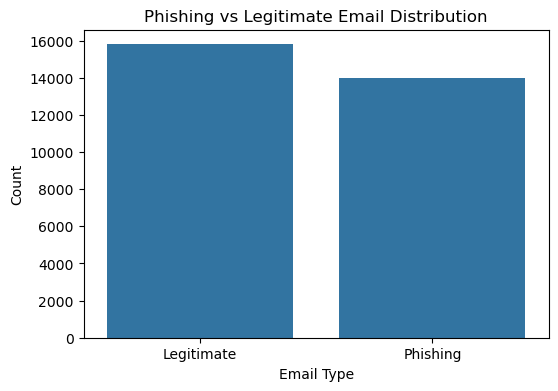

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='email_type', data=df)
plt.title('Phishing vs Legitimate Email Distribution')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.show()  

In [13]:
# Check first few rows again to understand the dataset better

df.head()

,subject,body,label,email_type
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0,Legitimate
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0,Legitimate
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0,Legitimate
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0,Legitimate
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0,Legitimate


In [14]:
# Display one phishing email sample

print(df[df['label'] == 1].iloc[0])

subject       d - link dwl - g 510 802 . 11 g wireless pci l...
body          $ 39 . 85 dwl - g 510\r\nhigh speed\r\n2 . 4\r...
label                                                         1
email_type                                             Phishing
Name: 3501, dtype: object


In [15]:
print(df.columns)

Index(['subject', 'body', 'label', 'email_type'], dtype='object')


In [16]:
# Create email length column using body text

df['email_length'] = df['body'].astype(str).apply(len)

# Display email text and length

df[['body', 'email_length']].head()

,body,email_length
0,( see attached file : hplno 525 . xls )\r\n- h...,58
1,- - - - - - - - - - - - - - - - - - - - - - fo...,1608
2,"estimated actuals\r\nmarch 30 , 2001\r\nno flo...",171
3,( see attached file : hplno 530 . xls )\r\n- h...,58
4,( see attached file : hplno 601 . xls )\r\n- h...,58


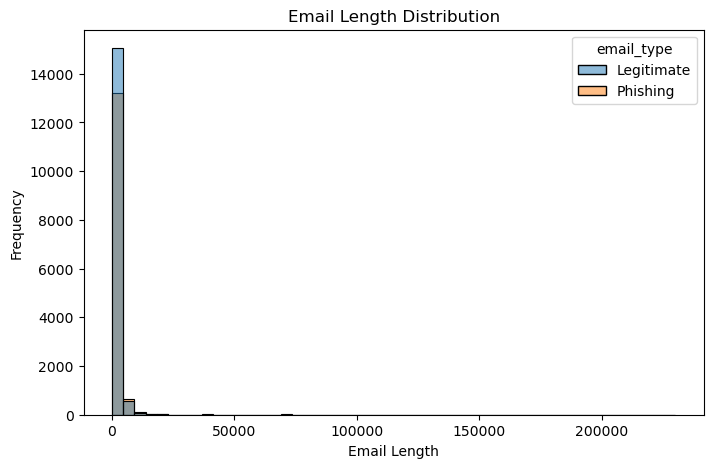

In [17]:
# Compare email length between phishing and legitimate emails

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='email_length', hue='email_type', bins=50)
plt.title('Email Length Distribution')
plt.xlabel('Email Length')
plt.ylabel('Frequency')
plt.show()

In [18]:
# Check average email length by class

df.groupby('email_type')['email_length'].mean()

email_type
Legitimate    1627.513457
Phishing      1329.990341
Name: email_length, dtype: float64

In [19]:
# Display top 5 longest emails

df[['email_type', 'email_length', 'body']].sort_values(by='email_length', ascending=False).head()

,email_type,email_length,body
11351,Legitimate,230120,enron : a wake - up call\r\nthe wall street jo...
11385,Legitimate,180073,"rival to buy enron , top energy trader , after..."
11352,Legitimate,166813,fall of a power giant : bailout is unlikely if...
11363,Legitimate,142681,accounting peer review gets more scrutiny\r\nt...
11358,Legitimate,137416,enron and dynegy discuss plan to cut price of ...


In [20]:
# Check for missing values in subject and body columns

print(df[['subject', 'body']].isnull().sum())

subject    198
body         0
dtype: int64


In [21]:
# Fill missing values with empty strings

df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

In [22]:
# Combine subject and body into one text column

df['email_text'] = df['subject'] + ' ' + df['body']

In [23]:
# Display combined text column

df[['subject', 'body', 'email_text']].head()

,subject,body,email_text
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,"hpl nom for may 25 , 2001 ( see attached file ..."
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,re : nom / actual vols for 24 th - - - - - - -...
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...","enron actuals for march 30 - april 1 , 201 est..."
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,"hpl nom for may 30 , 2001 ( see attached file ..."
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,"hpl nom for june 1 , 2001 ( see attached file ..."


In [24]:
# Create a function for text cleaning

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\\S+|www\\S+|https\\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = text.split()
    text = [word for word in text if word not in stop_words]
    text = [lemmatizer.lemmatize(word) for word in text]
    text = ' '.join(text)
    return text

In [25]:
# Apply cleaning function

df['cleaned_text'] = df['email_text'].apply(clean_text)

In [26]:
# Display original and cleaned text

df[['email_text', 'cleaned_text']].head()

,email_text,cleaned_text
0,"hpl nom for may 25 , 2001 ( see attached file ...",hpl nom may see attached file hplno xl hplno xl
1,re : nom / actual vols for 24 th - - - - - - -...,nom actual vols th forwarded sabrae zajac hou ...
2,"enron actuals for march 30 - april 1 , 201 est...",enron actuals march april estimated actualsmar...
3,"hpl nom for may 30 , 2001 ( see attached file ...",hpl nom may see attached file hplno xl hplno xl
4,"hpl nom for june 1 , 2001 ( see attached file ...",hpl nom june see attached file hplno xl hplno xl


In [27]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
# Define input and output variables

X = df['cleaned_text']
y = df['label']

In [29]:
# Convert text into TF-IDF features

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

In [30]:
# Check shape of transformed features

print(X_tfidf.shape)

(29767, 5000)


In [31]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
# Train Logistic Regression model

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
# Make predictions

y_pred = model.predict(X_test)

In [34]:
# Check model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.985387974470944


In [35]:
# Print classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3185
           1       0.98      0.99      0.98      2769

    accuracy                           0.99      5954
   macro avg       0.98      0.99      0.99      5954
weighted avg       0.99      0.99      0.99      5954



In [36]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3124   61]
 [  26 2743]]


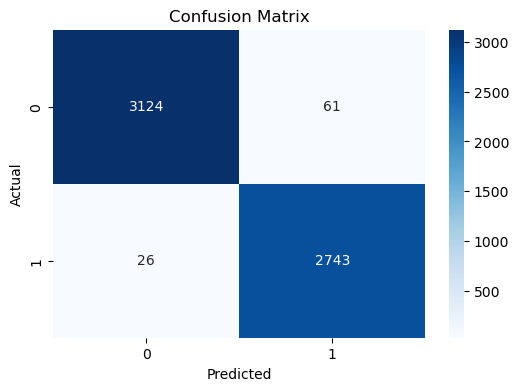

In [37]:
# Plot confusion matrix

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [39]:
# Create models folder if it does not exist

import os

os.makedirs('models', exist_ok=True)

In [40]:
import pickle

pickle.dump(svm_model, open('models/phishing_email_model.pkl', 'wb'))
pickle.dump(tfidf, open('models/tfidf_vectorizer.pkl', 'wb'))

In [41]:
# Load saved model and vectorizer

loaded_model = pickle.load(open('models/phishing_email_model.pkl', 'rb'))
loaded_vectorizer = pickle.load(open('models/tfidf_vectorizer.pkl', 'rb'))

In [42]:
# Test with a custom email

sample_email = """
Congratulations! Your bank account has been suspended.
Click the link below immediately to verify your account details.
"""

# Clean the email
cleaned_email = clean_text(sample_email)

# Convert text using saved vectorizer
email_vector = loaded_vectorizer.transform([cleaned_email])

# Predict using saved model
prediction = loaded_model.predict(email_vector)

if prediction[0] == 1:
    print("This email is predicted as: Phishing")
else:
    print("This email is predicted as: Legitimate")

This email is predicted as: Phishing


In [43]:
# Try another legitimate email

sample_email = """
Hi Team,

This is a reminder that tomorrow's meeting is scheduled for 10 AM.
Please be available in the conference room. 

Regards,
HR Team
"""

cleaned_email = clean_text(sample_email)
email_vector = loaded_vectorizer.transform([cleaned_email])

prediction = loaded_model.predict(email_vector)

if prediction[0] == 1:
    print("This email is predicted as: Phishing")
else:
    print("This email is predicted as: Legitimate")

This email is predicted as: Legitimate


In [44]:
# Check current files inside models folder

os.listdir('models')

['tfidf_vectorizer.pkl', 'phishing_email_model.pkl']

In [45]:
# Check predictions on test dataset

test_predictions = loaded_model.predict(X_test)

In [46]:
# Create a dataframe to compare actual vs predicted values

results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': test_predictions
})

results_df.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [47]:
# Add email text also for easier checking

test_texts = X.iloc[y_test.index]

results_df = pd.DataFrame({
    'Email_Text': test_texts.values,
    'Actual': y_test.values,
    'Predicted': test_predictions
})

results_df.head(20)

,Email_Text,Actual,Predicted
0,karthik rajan interview schedule attached find...,0,0
1,al ad hoc review team week th th th fine th be...,0,0
2,sale u e usb voip handset w built audio adapte...,1,1
3,pharma stop wasting money prescription drug ge...,1,1
4,california update puc turn davis proposed rate...,0,0
5,ethylene margin collar model dear let u meet e...,0,0
6,start date hourahead hour start date hourahead...,0,0
7,koch three river outage scheduled effect throu...,0,0
8,power failure guy contingency plan manage outa...,0,0
9,union carbide seadrift darensitara meter look ...,0,0


In [48]:
# Convert numeric labels into readable labels

results_df['Actual_Label'] = results_df['Actual'].map({0: 'Legitimate', 1: 'Phishing'})
results_df['Predicted_Label'] = results_df['Predicted'].map({0: 'Legitimate', 1: 'Phishing'})

In [49]:
# Display final comparison

results_df[['Email_Text', 'Actual_Label', 'Predicted_Label']].head(20)

,Email_Text,Actual_Label,Predicted_Label
0,karthik rajan interview schedule attached find...,Legitimate,Legitimate
1,al ad hoc review team week th th th fine th be...,Legitimate,Legitimate
2,sale u e usb voip handset w built audio adapte...,Phishing,Phishing
3,pharma stop wasting money prescription drug ge...,Phishing,Phishing
4,california update puc turn davis proposed rate...,Legitimate,Legitimate
5,ethylene margin collar model dear let u meet e...,Legitimate,Legitimate
6,start date hourahead hour start date hourahead...,Legitimate,Legitimate
7,koch three river outage scheduled effect throu...,Legitimate,Legitimate
8,power failure guy contingency plan manage outa...,Legitimate,Legitimate
9,union carbide seadrift darensitara meter look ...,Legitimate,Legitimate


In [50]:
# Show only wrong predictions

wrong_predictions = results_df[results_df['Actual'] != results_df['Predicted']]

wrong_predictions[['Email_Text', 'Actual_Label', 'Predicted_Label']].head(20)

,Email_Text,Actual_Label,Predicted_Label
179,cereal talk withpete long got emailfrom yester...,Phishing,Legitimate
235,know america giving away visa differentiable b...,Phishing,Legitimate
311,electric gas industry map special pennwell ele...,Legitimate,Phishing
439,welcome network world fusion focus jason meser...,Legitimate,Phishing
523,garaev pisani lover enlarge staying power fort...,Phishing,Legitimate
565,accrued breakdown day counterparties,Legitimate,Phishing
645,news alert sttc ob press releasesource softnet...,Phishing,Legitimate
815,great article mpgs put jail r e v e meastound ...,Phishing,Legitimate
819,relief earthquake victim el salvador saturday ...,Legitimate,Phishing
887,goodday captain ahoy tide high mermaid singing...,Legitimate,Phishing


In [51]:
n = int(input())

 5
